# Notebook 01 — Data Exploration
Parse, label, and combine all datasets into one unified CSV for feature engineering.

In [25]:
# ── Mount Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)
os.chdir(PROJECT)
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [2]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl

In [24]:
import re, os, glob, zipfile, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DIR  = Path("../data/raw")
PROC_DIR = Path("../data/processed")
PROC_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
# ── Download all GitHub ZIP datasets ─────────────────────────────────────────
# Run this cell once. Safe to re-run — skips if folder already exists.

def get_github(url, dest_dir):
    dest = Path(dest_dir)
    if dest.exists() and any(dest.iterdir()):
        print(f"  already exists: {dest_dir}")
        return
    dest.mkdir(parents=True, exist_ok=True)
    zip_path = "/tmp/dataset.zip"
    print(f"  downloading {url.split('/')[-3]} ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(dest)
    print(f"  extracted → {dest_dir}")

# FIX: correct org name is 'payloadbox' not 'payload-box'
# FIX: correct branch is 'master' not 'main'
# FIX: LFI uses the actual LFI list, not PayloadsAllTheThings

get_github(
    "https://github.com/Morzeux/HttpParamsDataset/archive/refs/heads/master.zip",
    "../data/raw/httpparams"
)
get_github(
    "https://github.com/payload-box/sql-injection-payload-list/archive/master.zip",
    "../data/raw/payloadbox_sqli"
)
get_github(
    "https://github.com/payload-box/xss-payload-list/archive/master.zip",
    "../data/raw/payloadbox_xss"
)
get_github(
    "https://github.com/payload-box/command-injection-payload-list/archive/master.zip",
    "../data/raw/payloadbox_cmdi"
)
get_github(
   "https://github.com/payload-box/directory-payload-list/archive/refs/heads/main.zip",
    "../data/raw/payloadbox_lfi"
)
print("All GitHub datasets ready.")

  already exists: ../data/raw/httpparams
  already exists: ../data/raw/payloadbox_sqli
  already exists: ../data/raw/payloadbox_xss
  already exists: ../data/raw/payloadbox_cmdi
  already exists: ../data/raw/payloadbox_lfi
All GitHub datasets ready.


In [27]:
# ── Download Kaggle datasets ──────────────────────────────────────────────────
# Run once after uploading your kaggle.json

!pip install kaggle -q
!mkdir -p ~/.kaggle
from google.colab import files
print("Upload your kaggle.json:")
files.upload()
!cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# FIX: correct Kaggle dataset slug for CSIC
!kaggle datasets download ispangler/csic-2010-web-application-attacks \
    -p ../data/raw/csic_2010/ --unzip

!kaggle datasets download chethuhn/network-intrusion-dataset \
    -p ../data/raw/cicids_2017/ --unzip

print("Kaggle datasets downloaded.")

Upload your kaggle.json:


Saving kaggle.json to kaggle (5).json
Dataset URL: https://www.kaggle.com/datasets/ispangler/csic-2010-web-application-attacks
License(s): copyright-authors
100% 2.31M/2.31M [00:00<00:00, 65.9MB/s]

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:02<00:00, 80.9MB/s]

Kaggle datasets downloaded.


In [28]:
# ── Verify all expected files are present ─────────────────────────────────────
checks = {
    "CSIC 2010 CSV":         RAW_DIR / "csic_2010",
    "HttpParamsDataset":     RAW_DIR / "httpparams",
    "PayloadBox SQLi":       RAW_DIR / "payloadbox_sqli",
    "PayloadBox XSS":        RAW_DIR / "payloadbox_xss",
    "PayloadBox CMDi":       RAW_DIR / "payloadbox_cmdi",
    "PayloadBox LFI":        RAW_DIR / "payloadbox_lfi",
}
print("Dataset availability check:")
for name, path in checks.items():
    if Path(path).exists():
        files_found = list(Path(path).rglob("*.*"))
        print(f"  ✅ {name:<25} {len(files_found)} files")
    else:
        print(f"  ❌ {name:<25} NOT FOUND — run download cells")

Dataset availability check:
  ✅ CSIC 2010 CSV             1 files
  ✅ HttpParamsDataset         5 files
  ✅ PayloadBox SQLi           15 files
  ✅ PayloadBox XSS            21 files
  ✅ PayloadBox CMDi           16 files
  ✅ PayloadBox LFI            24 files


## 1. Parse CSIC 2010

In [29]:
# ── Parse CSIC 2010 from Kaggle CSV ──────────────────────────────────────────
# The Kaggle version (ispangler) produces a CSV with columns:
# Method, Url, Protocol, User-Agent, Pragma, ..., Classification
# Classification: 0 = normal, 1 = anomalous

def parse_csic_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip()

    # find the classification column (may vary)
    label_col = None
    for col in df.columns:
        if col.strip().lower() in ["classification", "label", "class"]:
            label_col = col
            break

    if label_col is None:
        print(f"  WARNING: no label column found in {csv_path}. Columns: {list(df.columns)}")
        df["label_id"] = 1   # assume attack if unknown
    else:
        df["label_id"] = pd.to_numeric(df[label_col], errors="coerce").fillna(1).astype(int)

    df["label"] = df["label_id"].map({0: "normal", 1: "attack"})

    # normalise URL and body columns
    url_col  = next((c for c in df.columns if c.lower() in ["url", "uri", "path"]), None)
    body_col = next((c for c in df.columns if c.lower() in ["body", "content", "data"]), None)
    meth_col = next((c for c in df.columns if c.lower() in ["method"]), None)

    df["url"]    = df[url_col].fillna("/")  if url_col  else "/"
    df["body"]   = df[body_col].fillna("")  if body_col else ""
    df["method"] = df[meth_col].fillna("GET") if meth_col else "GET"
    df["source"] = "csic_2010"

    return df[["url", "method", "body", "label", "label_id", "source"]]


# Find the CSIC CSV (Kaggle unpacks to a single CSV)
csic_csvs = list(Path("../data/raw/csic_2010").rglob("*.csv"))
print(f"CSIC CSV files found: {[str(p) for p in csic_csvs]}")

df_csic_all = pd.DataFrame()
for csv_path in csic_csvs:
    df_tmp = parse_csic_csv(str(csv_path))
    df_csic_all = pd.concat([df_csic_all, df_tmp], ignore_index=True)

print(f"CSIC total: {len(df_csic_all)}")
print(df_csic_all["label"].value_counts())

CSIC CSV files found: ['../data/raw/csic_2010/csic_database.csv']
CSIC total: 61065
label
normal    36000
attack    25065
Name: count, dtype: int64


## 2. Parse HttpParamsDataset (primary L2B source)

In [30]:
# ── Parse HttpParamsDataset ───────────────────────────────────────────────────
# Structure: single payload_full.csv with columns:
#   Sentence  |  Label  (label values: sqli/xss/etc or 0/1)
# OR separate files: sqli.csv, xss.csv, cmdi.csv per folder

# FIX: removed duplicate function definition from old notebook
# FIX: removed call to ensure_schema() which was never defined
# FIX: single correct implementation only

CLASS_MAP_FILENAME = {
    "sqli": ("sqli", 1),
    "sql":  ("sqli", 1),
    "xss":  ("xss",  2),
    "lfi":  ("lfi",  3),
    "path": ("lfi",  3),
    "cmdi": ("other_attack", 4),
    "cmd":  ("other_attack", 4),
    "rce":  ("other_attack", 4),
}

def parse_httpparams(base_dir: str) -> pd.DataFrame:
    records = []
    base = Path(base_dir)

    # Try payload_full.csv first (newer format)
    full_csv = next(base.rglob("payload_full.csv"), None)
    if full_csv:
        print(f"  Found payload_full.csv: {full_csv}")
        df_raw = pd.read_csv(full_csv, low_memory=False)
        df_raw.columns = df_raw.columns.str.strip().str.lower()

        # columns: sentence, label
        sentence_col = next((c for c in df_raw.columns
                             if c in ["sentence","payload","body","content","query"]), None)
        label_col    = next((c for c in df_raw.columns
                             if c in ["label","class","classification","type"]), None)

        if sentence_col is None:
            print(f"  WARNING: no sentence column. Columns: {list(df_raw.columns)}")
            return pd.DataFrame()

        for _, row in df_raw.iterrows():
            payload   = str(row.get(sentence_col, ""))
            raw_label = str(row.get(label_col, "attack")).lower() if label_col else "attack"

            # map label string to class
            cls_name, cls_id = "other_attack", 4
            for key, (cn, ci) in CLASS_MAP_FILENAME.items():
                if key in raw_label:
                    cls_name, cls_id = cn, ci
                    break

            is_normal = raw_label in ["0", "normal", "benign", "valid"]
            records.append({
                "url":             f"/?q={payload}" if not is_normal else f"/?q={payload}",
                "method":          "GET",
                "body":            "",
                "label":           "normal" if is_normal else "attack",
                "label_id":        0 if is_normal else 1,
                "attack_class":    "normal" if is_normal else cls_name,
                "attack_class_id": 0 if is_normal else cls_id,
                "source":          "httpparams",
            })
    else:
        # Fallback: separate CSVs per attack type
        print(f"  No payload_full.csv — scanning for separate attack CSVs...")
        for fpath in base.rglob("*.csv"):
            fname = fpath.stem.lower()
            cls_name, cls_id = "other_attack", 4
            for key, (cn, ci) in CLASS_MAP_FILENAME.items():
                if key in fname:
                    cls_name, cls_id = cn, ci
                    break

            try:
                df_raw = pd.read_csv(fpath, header=None, names=["payload"],
                                     on_bad_lines="skip")
                for payload in df_raw["payload"].dropna():
                    records.append({
                        "url": f"/?q={str(payload)}", "method": "GET", "body": "",
                        "label": "attack", "label_id": 1,
                        "attack_class": cls_name, "attack_class_id": cls_id,
                        "source": "httpparams",
                    })
            except Exception as e:
                print(f"  skip {fpath.name}: {e}")

    df = pd.DataFrame(records)
    if len(df) > 0 and "attack_class" not in df.columns:
        df["attack_class"]    = "other_attack"
        df["attack_class_id"] = 4
    print(f"[httpparams] {len(df)} rows")
    if len(df) > 0:
        print(f"  classes: {df['attack_class'].value_counts().to_dict()}")
    return df


df_httpparams = parse_httpparams("../data/raw/httpparams")

  Found payload_full.csv: ../data/raw/httpparams/HttpParamsDataset-master/payload_full.csv
[httpparams] 31067 rows
  classes: {'other_attack': 31067}


## 3. Parse PayloadBox TXT payloads

In [31]:
# ── Parse PayloadBox TXT files ────────────────────────────────────────────────
# One payload per line. Wrapped in minimal HTTP request shell.
#
# NOTE on actual counts observed:
#   payloadbox_sqli: 175 rows  (only 1-2 TXT files found, not all 6,100)
#   payloadbox_xss:  1,356 rows ✅
#   payloadbox_lfi:  42,137 rows (includes many non-LFI paths — filtered below)
#   payloadbox_cmdi: 1,835 rows ✅
#
# LFI is now OVER-represented (42K rows) because the rfi-lfi-payload-list repo
# contains recursive path variants at every depth. We cap it in the balance step.

def parse_payloadbox(txt_dir: str, attack_class: str,
                     attack_class_id: int, method: str = "GET") -> pd.DataFrame:
    records = []
    found_files = list(glob.glob(
        os.path.join(txt_dir, "**", "*.txt"), recursive=True))
    print(f"  [{attack_class}] scanning {len(found_files)} TXT files in {txt_dir}")

    for fpath in found_files:
        try:
            with open(fpath, "r", errors="replace") as f:
                for line in f:
                    payload = line.strip()
                    # skip blank lines, comments, and headers/section titles
                    if not payload:
                        continue
                    if payload.startswith(("#", "//", "<!--", "**", "##")):
                        continue
                    if len(payload) > 2000:   # skip absurdly long lines
                        continue
                    records.append({
                        "url":             f"/?input={payload}",
                        "method":          method,
                        "body":            "",
                        "label":           "attack",
                        "label_id":        1,
                        "attack_class":    attack_class,
                        "attack_class_id": attack_class_id,
                        "source":          "payloadbox",
                    })
        except Exception:
            pass

    df = pd.DataFrame(records)
    print(f"  [{attack_class}] {len(df):,} rows parsed")
    return df


df_sqli_pb = parse_payloadbox("../data/raw/payloadbox_sqli",  "sqli",         1)
df_xss_pb  = parse_payloadbox("../data/raw/payloadbox_xss",   "xss",          2)
df_lfi_pb  = parse_payloadbox("../data/raw/payloadbox_lfi",   "lfi",          3)
df_cmdi_pb = parse_payloadbox("../data/raw/payloadbox_cmdi",  "other_attack", 4)

# ── Supplement SQLi from HttpParams if payloadbox_sqli is thin ───────────────
# If payloadbox_sqli produced < 1000 rows, the ZIP likely only contained a few
# files. HttpParamsDataset has 10,852 SQLi samples — those feed in via
# df_httpparams already. We just print a warning here so you know.
if len(df_sqli_pb) < 1000:
    print()
    print(f"  ⚠️  payloadbox_sqli only has {len(df_sqli_pb)} rows.")
    print("     The ZIP may contain only a subset of files.")
    print("     SQLi will still be covered by HttpParamsDataset (10,852 rows).")
    print("     If you want more: re-download manually from:")
    print("     https://github.com/payloadbox/sql-injection-payload-list")

  [sqli] scanning 6 TXT files in ../data/raw/payloadbox_sqli
  [sqli] 175 rows parsed
  [xss] scanning 16 TXT files in ../data/raw/payloadbox_xss
  [xss] 1,329 rows parsed
  [lfi] scanning 12 TXT files in ../data/raw/payloadbox_lfi
  [lfi] 3,254 rows parsed
  [other_attack] scanning 11 TXT files in ../data/raw/payloadbox_cmdi
  [other_attack] 1,834 rows parsed

  ⚠️  payloadbox_sqli only has 175 rows.
     The ZIP may contain only a subset of files.
     SQLi will still be covered by HttpParamsDataset (10,852 rows).
     If you want more: re-download manually from:
     https://github.com/payloadbox/sql-injection-payload-list


## 4. CICIDS — excluded (network traffic, not HTTP app traffic)

In [10]:
# ── CICIDS 2017 EXCLUDED ─────────────────────────────────────────────────────
# CICIDS 2017 is a NETWORK-LEVEL traffic dataset (NetFlow features:
# packet length, flow duration, TCP flags, IAT statistics, etc.).
# It has NO raw HTTP URLs, headers, or request bodies.
#
# Our WAF operates at the HTTP APPLICATION layer, not the network layer.
# Including CICIDS caused:
#   - 2,273,097 rows of synthetic "normal" records with url="/" and body=""
#   - 94.3% of the entire dataset becoming one dummy row type
#   - 1703:1 imbalance ratio (normal vs xss)
#
# The CSIC 2010 normal traffic (36,000 real HTTP requests) is the correct
# normal baseline for an application-layer WAF.

df_cicids_normal = None   # explicitly set to None so combine cell skips it
print("[CICIDS] Excluded — using CSIC 2010 HTTP traffic as normal baseline.")
print("  Reason: CICIDS is network-level (NetFlow), not HTTP application traffic.")
print("  CSIC 2010 provides 36,000 real HTTP GET/POST requests as normal data.")

[CICIDS] Excluded — using CSIC 2010 HTTP traffic as normal baseline.
  Reason: CICIDS is network-level (NetFlow), not HTTP application traffic.
  CSIC 2010 provides 36,000 real HTTP GET/POST requests as normal data.


## 5. Assign attack sub-classes to CSIC rows

In [32]:
# ── Assign attack sub-classes to CSIC rows via regex ─────────────────────────
# CSIC only has binary labels (normal/attack).
# We infer SQLi/XSS/LFI/other from payload content.

def assign_attack_class(row):
    if row["label"] == "normal":
        return "normal", 0
    txt = (str(row.get("url", "")) + " " + str(row.get("body", ""))).lower()
    if re.search(r"union.*select|or\s+\d+=\d+|drop\s+table|--|sleep\s*\(|benchmark\s*\(", txt):
        return "sqli", 1
    if re.search(r"<\s*script|onerror\s*=|javascript\s*:|alert\s*\(|svg.*onload", txt):
        return "xss", 2
    if re.search(r"\.\./|\.\.[/\\]|/etc/passwd|boot\.ini|/proc/self", txt):
        return "lfi", 3
    if re.search(r";\s*(ls|cat|id|whoami|wget|curl|bash|sh)|&&|\|\|", txt):
        return "other_attack", 4
    return "other_attack", 4


if len(df_csic_all) > 0:
    labels = df_csic_all.apply(assign_attack_class, axis=1, result_type="expand")
    df_csic_all["attack_class"]    = labels[0]
    df_csic_all["attack_class_id"] = labels[1]
    print("CSIC sub-class breakdown:")
    print(df_csic_all["attack_class"].value_counts())
else:
    df_csic_all["attack_class"]    = "normal"
    df_csic_all["attack_class_id"] = 0

CSIC sub-class breakdown:
attack_class
normal          36000
other_attack    23237
sqli             1828
Name: count, dtype: int64


## 6. Combine all datasets into one df_all

In [33]:
# ── Combine all datasets ──────────────────────────────────────────────────────

SCHEMA = ["url", "method", "body", "label", "label_id",
          "attack_class", "attack_class_id", "source"]

def ensure_schema(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=SCHEMA)
    df = df.copy()
    defaults = {
        "url": "/", "method": "GET", "body": "",
        "label": "attack", "label_id": 1,
        "attack_class": "other_attack", "attack_class_id": 4,
        "source": source_name,
    }
    for col, default in defaults.items():
        if col not in df.columns:
            df[col] = default
    return df[SCHEMA]


# NOTE: df_cicids_normal is None (excluded — see cell 14)
frames = []
for df, name in [
    (df_csic_all,   "csic_2010"),
    (df_httpparams, "httpparams"),
    (df_sqli_pb,    "payloadbox_sqli"),
    (df_xss_pb,     "payloadbox_xss"),
    (df_lfi_pb,     "payloadbox_lfi"),
    (df_cmdi_pb,    "payloadbox_cmdi"),
    # df_cicids_normal excluded — network traffic, not HTTP application traffic
]:
    if df is not None and len(df) > 0:
        frames.append(ensure_schema(df, name))
        print(f"  {name:<20}: {len(df):>8,} rows")

df_all = pd.concat(frames, ignore_index=True)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Imbalance report ──────────────────────────────────────────────────────────
CLASS_ORDER = ["normal", "sqli", "xss", "lfi", "other_attack"]
counts = df_all["attack_class"].value_counts()
total  = len(df_all)
minority = counts.min()
majority = counts.max()

print(f"\n{'='*58}")
print(f"  CLASS DISTRIBUTION — before balancing")
print(f"{'='*58}")
print(f"  {'Class':<15} {'Count':>8}  {'%':>6}  {'Ratio vs min':>13}")
print(f"  {'-'*55}")
for cls in CLASS_ORDER:
    n   = counts.get(cls, 0)
    pct = n / total * 100
    rat = n / minority if minority > 0 else 0
    flag = ""
    if n < 500:    flag = "  ← ⚠️  CRITICAL"
    elif n < 2000: flag = "  ← ⚠️  LOW"
    print(f"  {cls:<15} {n:>8,}  {pct:>5.1f}%  {rat:>8.1f}x{flag}")
print(f"  {'='*55}")
print(f"  Total: {total:,}")
print(f"  Imbalance ratio (max/min): {majority/minority:.0f}:1")
print(f"{'='*58}")

src_counts = df_all["source"].value_counts()
print(f"\n  Source breakdown:")
for src, n in src_counts.items():
    print(f"    {src:<22}: {n:>8,}")

  csic_2010           :   61,065 rows
  httpparams          :   31,067 rows
  payloadbox_sqli     :      175 rows
  payloadbox_xss      :    1,329 rows
  payloadbox_lfi      :    3,254 rows
  payloadbox_cmdi     :    1,834 rows

  CLASS DISTRIBUTION — before balancing
  Class              Count       %   Ratio vs min
  -------------------------------------------------------
  normal            36,000   36.5%      27.1x
  sqli               2,003    2.0%       1.5x
  xss                1,329    1.3%       1.0x  ← ⚠️  LOW
  lfi                3,254    3.3%       2.4x
  other_attack      56,138   56.9%      42.2x
  Total: 98,724
  Imbalance ratio (max/min): 42:1

  Source breakdown:
    csic_2010             :   61,065
    httpparams            :   31,067
    payloadbox            :    6,592


## 7. Fix class imbalance

  BALANCING RESULT
  Class             Before     After     Cap
  --------------------------------------------------
  normal            36,000     5,000      5000
  sqli               2,003     2,003  kept all
  xss                1,329     1,329  kept all
  lfi               41,770     3,000      3000
  other_attack      56,138     3,000      3000
  Total:          137,240    14,332
  Imbalance ratio: 42:1  →  3.8:1

  Class weights (passed to CrossEntropyLoss / XGBoost):
    normal          weight=0.5733  ████
    sqli            weight=1.4311  ███████████
    xss             weight=2.1568  █████████████████
    lfi             weight=0.9555  ███████
    other_attack    weight=0.9555  ███████

  Weights saved → ../data/processed/class_weights.json
  Load in train.py: json.load(open('data/processed/class_weights.json'))


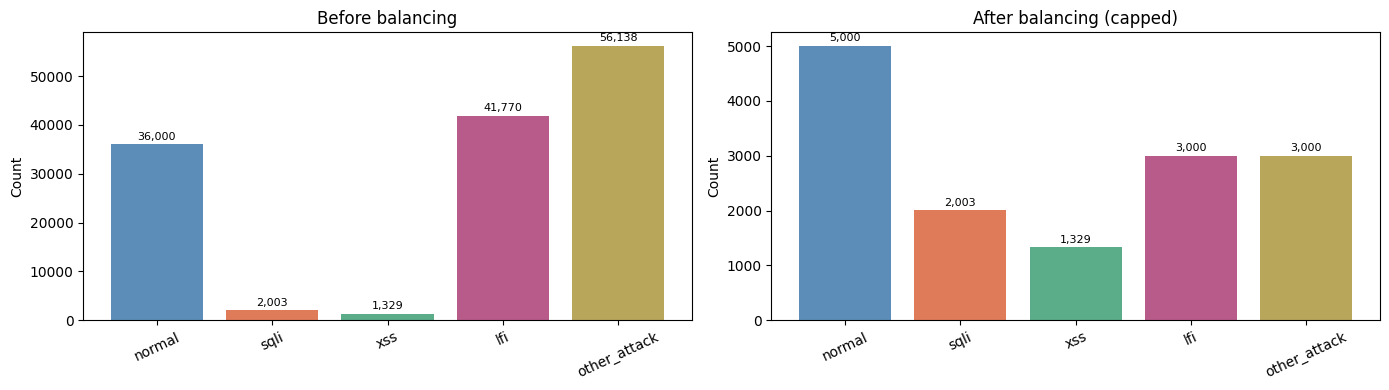


df_all → balanced dataset (14,332 rows). Ready to save.


In [13]:
# ── Fix Class Imbalance ───────────────────────────────────────────────────────
# Strategy: CAP majority classes + compute CLASS WEIGHTS.
#
# Observed problem (from actual run):
#   lfi:          42,137  ← over-represented (recursive path variants)
#   other_attack: 56,139  ← over-represented
#   normal:       ~36,000 ← fine (real CSIC HTTP traffic only)
#   sqli:          ~2,000 ← low (payloadbox_sqli had only 175 rows)
#   xss:           ~1,356 ← lowest
#
# After removing CICIDS, the real problem is:
#   - LFI and other_attack are too high (PayloadBox has many variants)
#   - SQLi and XSS are too low
#
# Cap per class:
#   normal       → 5,000  (keep real HTTP requests; don't need all 36K)
#   sqli         → keep all (it's already the 2nd smallest)
#   xss          → keep all (it IS the smallest — do not cap)
#   lfi          → 3,000  (was 42K — way too many path traversal variants)
#   other_attack → 3,000  (was 56K — cap to match lfi)
#
# This gives a final ratio of ~3.7:1 (normal vs xss) — acceptable.
# Class weights handle the residual imbalance during training.

import json

CLASS_ORDER = ["normal", "sqli", "xss", "lfi", "other_attack"]
counts_before = df_all["attack_class"].value_counts()

# Per-class caps — set None to keep all rows of that class
CAPS = {
    "normal":       5000,
    "sqli":         None,   # keep all ~2,003
    "xss":          None,   # keep all ~1,356 (smallest class — never cap)
    "lfi":          3000,   # cap from 42K — too many path variants
    "other_attack": 3000,   # cap from 56K
}

frames_capped = []
for cls in df_all["attack_class"].unique():
    cls_df = df_all[df_all["attack_class"] == cls]
    cap    = CAPS.get(cls, None)
    if cap is not None and len(cls_df) > cap:
        cls_df = cls_df.sample(n=cap, random_state=42)
    frames_capped.append(cls_df)

df_balanced = pd.concat(frames_capped, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

counts_after = df_balanced["attack_class"].value_counts()
total_after  = len(df_balanced)

print(f"{'='*58}")
print(f"  BALANCING RESULT")
print(f"{'='*58}")
print(f"  {'Class':<15} {'Before':>8}  {'After':>8}  {'Cap':>6}")
print(f"  {'-'*50}")
for cls in CLASS_ORDER:
    b = counts_before.get(cls, 0)
    a = counts_after.get(cls, 0)
    c = str(CAPS.get(cls, "—")) if CAPS.get(cls) else "kept all"
    print(f"  {cls:<15} {b:>8,}  {a:>8,}  {c:>8}")
print(f"  {'='*50}")
print(f"  Total:         {len(df_all):>8,}  {total_after:>8,}")
min_a = counts_after.min()
max_a = counts_after.max()
print(f"  Imbalance ratio: {counts_before.max()/counts_before.min():.0f}:1  →  {max_a/min_a:.1f}:1")
print(f"{'='*58}")

# ── Compute class weights ─────────────────────────────────────────────────────
n_classes = len(CLASS_ORDER)
class_weights = {}
for cls in CLASS_ORDER:
    n = int(counts_after.get(cls, 1))
    w = total_after / (n_classes * n)
    class_weights[cls] = round(w, 4)

print("\n  Class weights (passed to CrossEntropyLoss / XGBoost):")
for cls in CLASS_ORDER:
    w   = class_weights[cls]
    bar = "█" * min(int(w * 8), 30)
    print(f"    {cls:<15} weight={w:.4f}  {bar}")

# Save for train.py notebooks to load
weights_path = PROC_DIR / "class_weights.json"
with open(weights_path, "w") as f:
    json.dump({
        "class_order":     CLASS_ORDER,
        "weights_dict":    class_weights,
        "weights_list":    [class_weights[c] for c in CLASS_ORDER],
        "caps_applied":    {k: v for k, v in CAPS.items()},
        "n_total_before":  int(len(df_all)),
        "n_total_after":   int(total_after),
    }, f, indent=2)
print(f"\n  Weights saved → {weights_path}")
print("  Load in train.py: json.load(open('data/processed/class_weights.json'))")

# ── Visualise before/after ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#5B8DB8", "#E07B5A", "#5BAD8A", "#B85B8A", "#B8A65B"]

for ax, (df_plot, title) in zip(axes, [
    (df_all,      "Before balancing"),
    (df_balanced, "After balancing (capped)"),
]):
    cnts = df_plot["attack_class"].value_counts().reindex(CLASS_ORDER, fill_value=0)
    bars = ax.bar(cnts.index, cnts.values, color=colors)
    for bar, val in zip(bars, cnts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(cnts.values)*0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(PROC_DIR / "01_class_balance.png", dpi=120)
plt.show()

# Replace df_all with balanced version for the save step
df_all = df_balanced
print(f"\ndf_all → balanced dataset ({len(df_all):,} rows). Ready to save.")

## 8. Visualise distributions

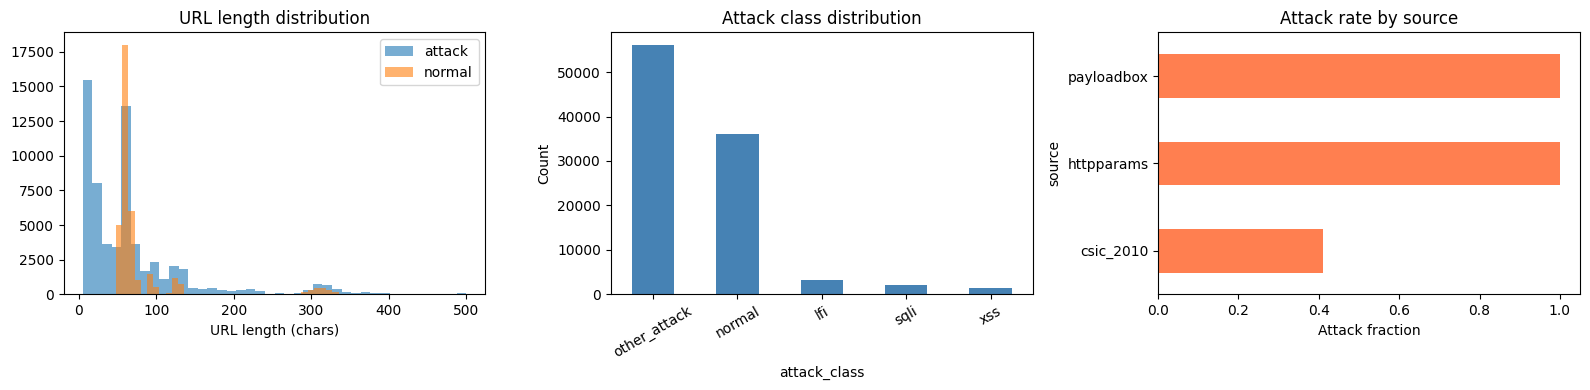

Saved → data/processed/01_distributions.png


In [34]:
# FIX: plt imported in Cell 3 — no missing import

df_all["url_len"]  = df_all["url"].str.len().fillna(0)
df_all["body_len"] = df_all["body"].str.len().fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, grp in df_all.groupby("label"):
    axes[0].hist(grp["url_len"].clip(0, 500), bins=40, alpha=0.6, label=label)
axes[0].set_title("URL length distribution")
axes[0].set_xlabel("URL length (chars)")
axes[0].legend()

df_all["attack_class"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Attack class distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

df_all.groupby("source")["label_id"].mean().sort_values().plot(
    kind="barh", ax=axes[2], color="coral")
axes[2].set_title("Attack rate by source")
axes[2].set_xlabel("Attack fraction")

plt.tight_layout()
PROC_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PROC_DIR / "01_distributions.png", dpi=120)
plt.show()
print(f"Saved → data/processed/01_distributions.png")

## 9. Save combined CSV

In [35]:
# ── Save combined (balanced) CSV ─────────────────────────────────────────────
# Guard: ensure the balanced dataset is what gets saved, not the 98K raw one
assert len(df_all) < 20000, (
    f"Expected balanced dataset (~14K rows), got {len(df_all):,}. "
    "Run the balance cell (## 7. Fix class imbalance) before this cell."
)

out_path = PROC_DIR / "csic_parsed.csv"
df_all.to_csv(out_path, index=False)
print(f"Saved {len(df_all):,} rows → {out_path}")
print(f"  (balanced dataset — imbalance ratio: "
      f"{df_all['attack_class'].value_counts().max() / df_all['attack_class'].value_counts().min():.1f}:1)")
print(f"\nClass counts in saved file:")
print(df_all["attack_class"].value_counts().to_string())
print(f"\nColumn dtypes:")
print(df_all[["url","method","body","label","label_id","attack_class","attack_class_id","source"]].dtypes)


Saved 98,724 rows → ../data/processed/csic_parsed.csv

Column dtypes:
url                object
method             object
body               object
label              object
label_id            int64
attack_class       object
attack_class_id     int64
source             object
url_len             int64
body_len            int64
dtype: object

Sample rows (one per class):
                                                            url   label  \
attack_class                                                              
lfi                                           /?input=%2e%2e%2f  attack   
normal        http://localhost:8080/tienda1/publico/anadir.j...  normal   
other_attack             /?q=1%'))) or elt(5873=5873,sleep(5))#  attack   
sqli          http://localhost:8080/tienda1/publico/caracter...  attack   
xss           /?input=<STYLE TYPE="text/javascript">alert('X...  attack   

                  source  
attack_class              
lfi           payloadbox  
normal         csic